# 잡코리아 Job Market 분석

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 보기 좋은 출력 설정
pd.set_option('display.max_rows', None)        # 모든 행 출력
pd.set_option('display.max_columns', None)     # 모든 열 출력
pd.set_option('display.width', None)           # 출력 폭 자동 조절
pd.set_option('display.max_colwidth', None)    # 긴 문자열도 잘리지 않게

# 0. 페이지 번호를 바꿔가면 채용공고를 파싱하는 함수

- 동시에 각 페이지에서 각 공고의 제목,회사명, 지역 정보를 추출
- 추출한 것을 리스트 형태로 반환

In [2]:

# 한 페이지의 채용공고를 파싱하는 함수
def parse_jobkorea_page(page_num):
    # 크롤링 URL
    url = f"https://www.jobkorea.co.kr/Search?stext=data+scientist&local=I000&&Page_No={page_num}"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    response = requests.get(url, headers=headers) # User-Agent 설정으로, 브라우저에서 요청한 것처럼 서버를 속인다.
    response.encoding = 'utf-8' # HTML 인코딩 지정
    soup = BeautifulSoup(response.text, 'html.parser') # HTML 문서를 Python 객체로 변환



    # 공고 항목 찾기
    job_blocks = soup.select('div.styles_mb_space2__dk46ts4t') # 채용공고 태그 위치는 styles_mb_space2__dk46ts4t 클래스이다.
    jobs = []

    for ss0 in job_blocks:
        # 채용 공고 제목
        title = ss0.find_all('a')[0].text.strip() # a 태그에 바로 붙어있는 텍스트가 채용 공고 제목이다.

        # 회사 이름
        company_tag = ss0.find_next('a', class_='styles_mb_space20__dk46ts2h')
        if company_tag:
            company = company_tag.find('span').text.strip()
        else:
            company = None
        # 회사 이름 태그 위치는 sso 위치 아래에 있는 a 태그의 styles_mb_space20__dk46ts2h 클래스를 지나서 span 태그에 있는 텍스트이다.
        # find_next : 현재 태그 기준으로 HTML에서 다음 나타나는 특정 태그 찾음. (a는 찾으려는 태그, 그리고 클래스)


        
        # 회사 위치
        if company_tag:
            location_tag = company_tag.find_next('span', class_='Typography_variant_size14__344nw27')

        else:
            location_tag = None

        if location_tag:
            location = location_tag.text.strip()
        else:
            location = None
        # 위치 태그는 회사 이름 태그 다음에 있는 span 태그의 Typography_variant_size14__344nw27 클래스이다.
        
        #print(title, company, location)

        jobs.append([title, company, location])

    return jobs


# 1. 페이지 번호를 바꿔가며 여러 페이지의 채용 게시글을 가져오기

- 동시에 각 페이지에서 각 공고의 제목,회사명, 지역 정보를 추출
- 추출한 것을 리스트로 저장

In [3]:

# 여러 페이지 반복해서 데이터 수집


all_data = []
page=1


while True:
    print(f"{page} 페이지 크롤링 중...")

    data = parse_jobkorea_page(page)  
    if len(data) == 0: #페이지에서 받아온 데이터가 없으면 마지막 페이지이다.
        print("마지막 페이지입니다.")
        break

    all_data.extend(data)
    page += 1
    
print(f"총 {len(all_data)}개의 채용공고 수집 완료")

1 페이지 크롤링 중...
2 페이지 크롤링 중...
3 페이지 크롤링 중...
4 페이지 크롤링 중...
5 페이지 크롤링 중...
6 페이지 크롤링 중...
7 페이지 크롤링 중...
8 페이지 크롤링 중...
9 페이지 크롤링 중...
10 페이지 크롤링 중...
11 페이지 크롤링 중...
12 페이지 크롤링 중...
13 페이지 크롤링 중...
14 페이지 크롤링 중...
15 페이지 크롤링 중...
16 페이지 크롤링 중...
17 페이지 크롤링 중...
18 페이지 크롤링 중...
마지막 페이지입니다.
총 334개의 채용공고 수집 완료


# 2. 추출한 것을 저장한 리스트를 pandas.DataFrame 으로 정리

In [4]:
# DataFrame으로 정리 및 저장

df = pd.DataFrame(all_data) #리스트를 DataFrame으로 변환
df.drop_duplicates(inplace=True) # DataFrame에서 중복된 행을 제거한다.
df.columns = ["Title", "Company", "Location"] #열의 이름을 설정한다.



# 3. CSV 파일로 저장

In [5]:
# CSV 저장( 한글 깨짐 방지를 위해 "utf-8-sig" 사용)
df.to_csv("jobkorea_data_scientist.csv", index=False, encoding="utf-8-sig")
#print("jobkorea_data_scientist.csv 파일 저장 완료")

#상위 10개 출력
print(df.head(10))


#앞서 저장한 csv 파일 출력
csvData = pd.read_csv("jobkorea_data_scientist.csv", encoding="utf-8-sig")
csvData = csvData[['Title', 'Company', 'Location']]
csvData.head(50)  # 상위 50개만 미리보기

                                          Title     Company Location
0                          [PTKOREA] 데이터 사이언티스트  펑타이그레이터차이나   서울 강남구
1                             데이터 사이언티스트 (Lead)          핀다   서울 강남구
2              [CJ 그룹-CJ 메조미디어] 데이터 사이언티스트 경력채용   ㈜씨제이메조미디어    서울 중구
3                            데이터 사이언티스트 (5년 이상)         ㈜엑셈   서울 강서구
4                           데이터 사이언티스트(General)         ㈜컬리   서울 강남구
5  [미리디] 시니어 데이터 사이언티스트 (Senior Data Scientist)        ㈜미리디   서울 구로구
6        고객 데이터 사이언티스트(Customer Data Scientist)      ㈜메이머스트   경기 하남시
7                 [중견기업/IT] 데이터 사이언티스트 신입/경력 채용     ㈜데이타솔루션   서울 강남구
8                             데이터 사이언티스트 경력자 채용       ㈜캐롯아이   서울 강남구
9                           데이터 사이언티스트 (데이터분석가)     ㈜알라딘시스템   경기 고양시


,Title,Company,Location
0,[PTKOREA] 데이터 사이언티스트,펑타이그레이터차이나,서울 강남구
1,데이터 사이언티스트 (Lead),핀다,서울 강남구
2,[CJ 그룹-CJ 메조미디어] 데이터 사이언티스트 경력채용,㈜씨제이메조미디어,서울 중구
3,데이터 사이언티스트 (5년 이상),㈜엑셈,서울 강서구
4,데이터 사이언티스트(General),㈜컬리,서울 강남구
5,[미리디] 시니어 데이터 사이언티스트 (Senior Data Scientist),㈜미리디,서울 구로구
6,고객 데이터 사이언티스트(Customer Data Scientist),㈜메이머스트,경기 하남시
7,[중견기업/IT] 데이터 사이언티스트 신입/경력 채용,㈜데이타솔루션,서울 강남구
8,데이터 사이언티스트 경력자 채용,㈜캐롯아이,서울 강남구
9,데이터 사이언티스트 (데이터분석가),㈜알라딘시스템,경기 고양시


C:\Users\c\AppData\Local\Temp\ipykernel_28064\639234086.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.values, y=location_counts.index, palette="viridis")


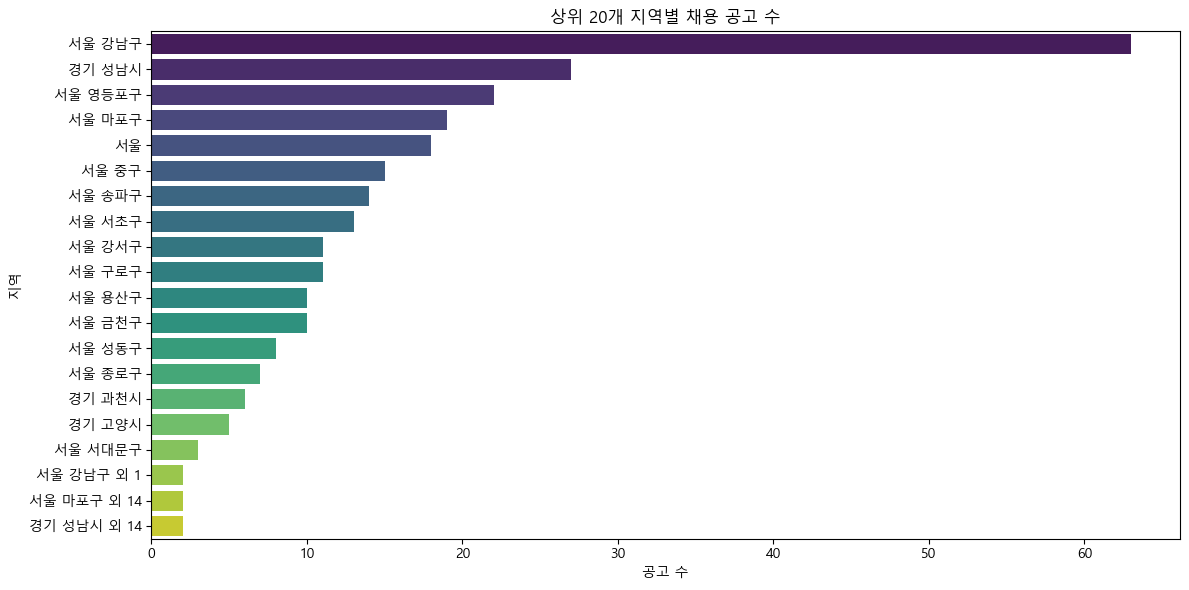

C:\Users\c\AppData\Local\Temp\ipykernel_28064\639234086.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=company_counts.values, y=company_counts.index, palette="magma")


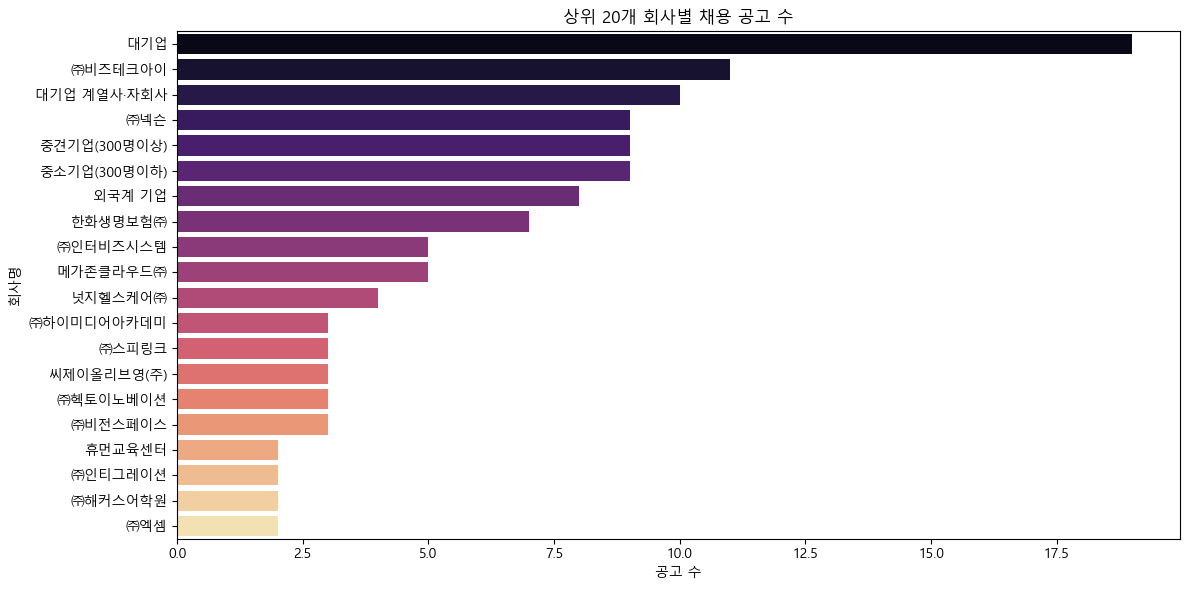

C:\Users\c\AppData\Local\Temp\ipykernel_28064\639234086.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="coolwarm")


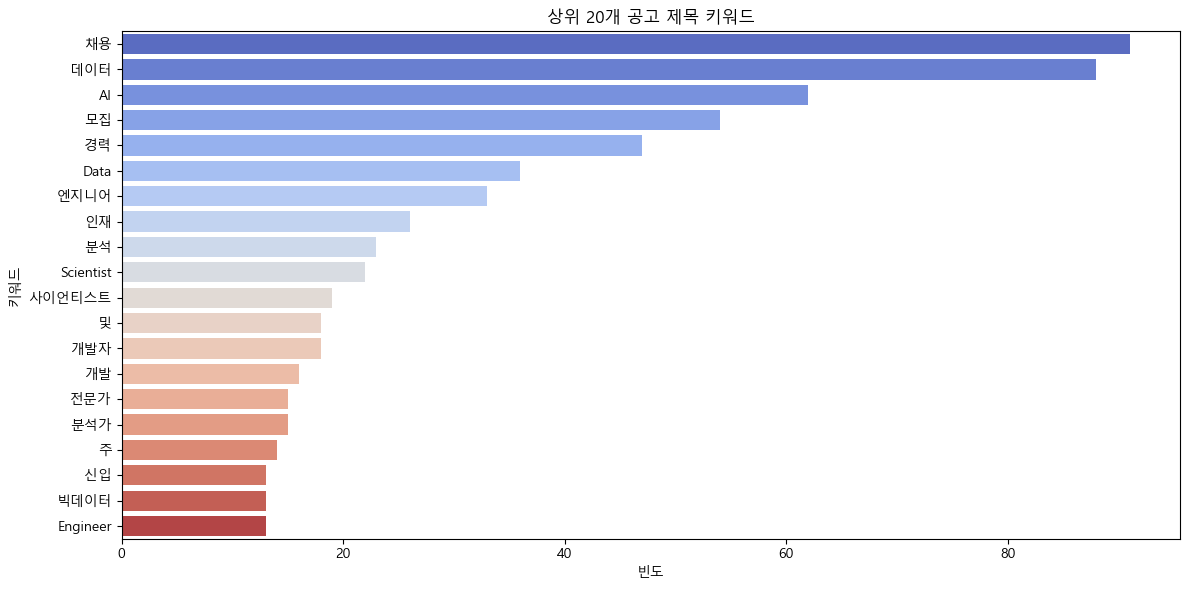

In [6]:

# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 지역별 공고 수
location_counts = df['Location'].value_counts().head(20)  # 상위 20개 지역만 표시
plt.figure(figsize=(12,6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette="viridis")
plt.title("상위 20개 지역별 채용 공고 수")
plt.xlabel("공고 수")
plt.ylabel("지역")
plt.tight_layout()
plt.show()

# 2. 회사별 공고 수 (상위 20개)
company_counts = df['Company'].value_counts().head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=company_counts.values, y=company_counts.index, palette="magma")
plt.title("상위 20개 회사별 채용 공고 수")
plt.xlabel("공고 수")
plt.ylabel("회사명")
plt.tight_layout()
plt.show()

# 3. 공고 제목 키워드 분석 (상위 20)
from collections import Counter
import re

# 공고 제목 텍스트 모두 합치기
titles_text = ' '.join(df['Title'].dropna().tolist())
# 단어 단위로 분리, 특수문자 제거
words = re.findall(r'\b\w+\b', titles_text)
word_counts = Counter(words)
# 상위 20개 키워드
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), palette="coolwarm")
plt.title("상위 20개 공고 제목 키워드")
plt.xlabel("빈도")
plt.ylabel("키워드")
plt.tight_layout()
plt.show()